# 🍽️ Restaurant Demand Forecasting System
## Project 3 — End-to-End Machine Learning Pipeline

---

### Project Overview

This notebook builds a **complete demand forecasting system** for a restaurant chain operating across multiple fulfillment centers. The goal is to predict weekly food order volumes (`num_orders`) for each center-meal combination using historical data, promotional signals, pricing, and meal metadata.

### Dataset Description

| Column | Description |
|---|---|
| `id` | Unique record identifier |
| `week` | Week number (1–145) |
| `center_id` | Fulfillment center ID (77 unique) |
| `meal_id` | Meal ID (51 unique) |
| `checkout_price` | Final price customer pays |
| `base_price` | Original price before discount |
| `emailer_for_promotion` | Binary: email promotion active |
| `homepage_featured` | Binary: featured on homepage |
| `num_orders` | **Target** — weekly order count |
| `category` | Meal category (14 types) |
| `cuisine` | Cuisine type (Thai/Indian/Italian/Continental) |
| `dish_name` | Dish name |
| `Ingredients` | Ingredient list |

### Pipeline Steps
1. Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Data Preprocessing
4. Model Training (Linear Regression, Random Forest, XGBoost, LightGBM)
5. Model Evaluation & Comparison
6. Prediction & Business Insights

---
## 📦 Section 1: Imports & Setup

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = sns.color_palette('Set2', 10)

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Environment & Database
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Gradient boosting
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed — skipping. Install with: pip install xgboost')

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print('LightGBM not installed — skipping. Install with: pip install lightgbm')

import math
from scipy import stats

print('✅ All imports successful!')
print(f'  XGBoost available: {XGB_AVAILABLE}')
print(f'  LightGBM available: {LGB_AVAILABLE}')

✅ All imports successful!
  XGBoost available: True
  LightGBM available: True


In [2]:
# Load environment variables
load_dotenv()

# Create PostgreSQL connection string
connection_string = (
    f"postgresql://{os.getenv('user')}:"
    f"{os.getenv('password')}@"
    f"{os.getenv('host')}:"
    f"{os.getenv('port')}/"
    f"{os.getenv('dbname')}"
)

# Create database engine
engine = create_engine(connection_string)

print("Connection engine created successfully.")

Connection engine created successfully.


---
## 📂 Section 2: Data Loading & Initial Inspection

In [3]:
# Load data
query = "SELECT * FROM restaurant_training_features"

df = pd.read_sql(query, engine)

print('='*55)
print(f'  Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('='*55)
print()
print('First 5 rows:')
df.head()

  Dataset Shape: 456,548 rows × 11 columns

First 5 rows:


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian


In [4]:
# Data types and memory usage
print('Column Data Types:')
print(df.dtypes)
print()
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Column Data Types:
id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
category                     str
cuisine                      str
dtype: object

Memory usage: 91.50 MB


In [5]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Value Summary:')
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else '✅ No missing values!')

Missing Value Summary:
✅ No missing values!


In [6]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [7]:
# Unique value counts for key columns
print('Key Column Cardinalities:')
print(f"  Weeks:       {df['week'].nunique()} (range: {df['week'].min()}–{df['week'].max()})")
print(f"  Centers:     {df['center_id'].nunique()}")
print(f"  Meals:       {df['meal_id'].nunique()}")
print(f"  Categories:  {df['category'].nunique()} → {df['category'].unique().tolist()}")
print(f"  Cuisines:    {df['cuisine'].nunique()} → {df['cuisine'].unique().tolist()}")
print()
print('Target Variable (num_orders) summary:')
print(df['num_orders'].describe())

Key Column Cardinalities:
  Weeks:       145 (range: 1–145)
  Centers:     77
  Meals:       51
  Categories:  14 → ['Beverages', 'Rice Bowl', 'Starters', 'Pasta', 'Sandwich', 'Biryani', 'Extras', 'Pizza', 'Seafood', 'Other Snacks', 'Desert', 'Soup', 'Salad', 'Fish']
  Cuisines:    4 → ['Thai', 'Indian', 'Italian', 'Continental']

Target Variable (num_orders) summary:
count    456548.000000
mean        261.872760
std         395.922798
min          13.000000
25%          54.000000
50%         136.000000
75%         324.000000
max       24299.000000
Name: num_orders, dtype: float64


---
## 📊 Section 3: Exploratory Data Analysis (EDA)

We analyze the target variable distribution, temporal patterns, pricing effects, and promotional impacts.

### 3.1 Target Variable Distribution

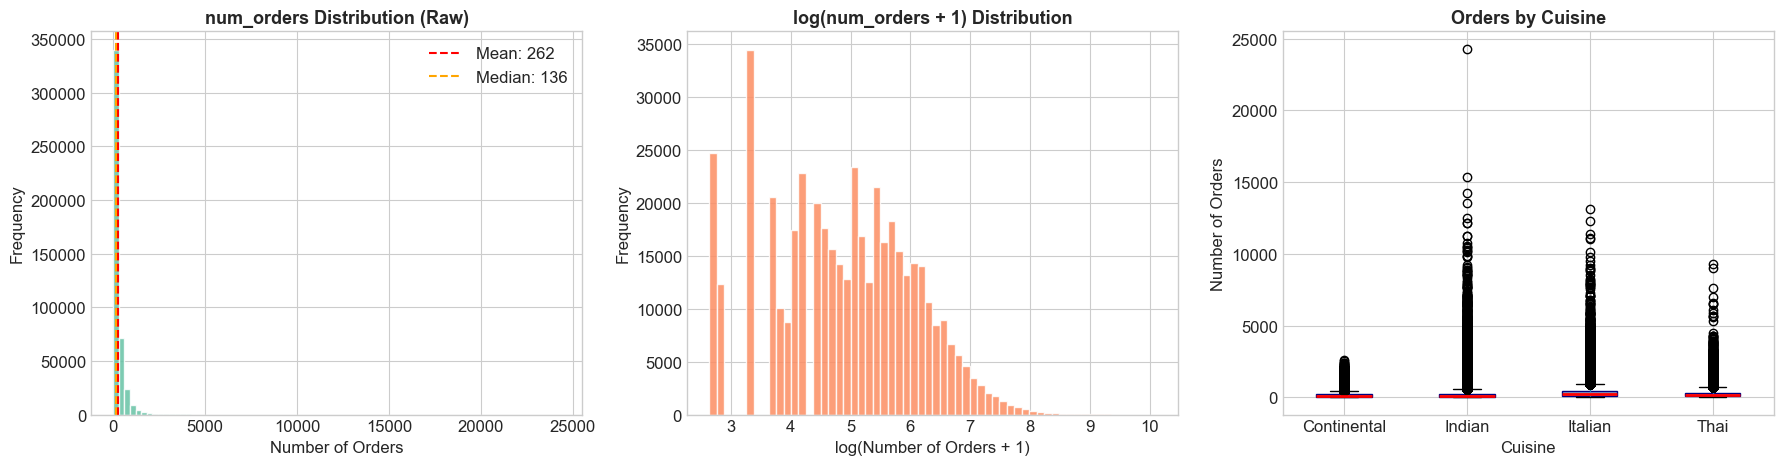

Raw skewness:         6.930
Log-transformed skew: -0.022
→ Log transformation significantly reduces skewness for better model performance.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution
axes[0].hist(df['num_orders'], bins=80, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].set_title('num_orders Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['num_orders'].mean(), color='red', linestyle='--', label=f"Mean: {df['num_orders'].mean():.0f}")
axes[0].axvline(df['num_orders'].median(), color='orange', linestyle='--', label=f"Median: {df['num_orders'].median():.0f}")
axes[0].legend()

# Log-transformed
log_orders = np.log1p(df['num_orders'])
axes[1].hist(log_orders, bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].set_title('log(num_orders + 1) Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Number of Orders + 1)')
axes[1].set_ylabel('Frequency')

# Box plot by cuisine
df.boxplot(column='num_orders', by='cuisine', ax=axes[2], 
           patch_artist=True,
           boxprops=dict(facecolor=PALETTE[2], color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Orders by Cuisine', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Cuisine')
axes[2].set_ylabel('Number of Orders')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Skewness
print(f'Raw skewness:         {df["num_orders"].skew():.3f}')
print(f'Log-transformed skew: {log_orders.skew():.3f}')
print('→ Log transformation significantly reduces skewness for better model performance.')

### 3.2 Temporal Patterns

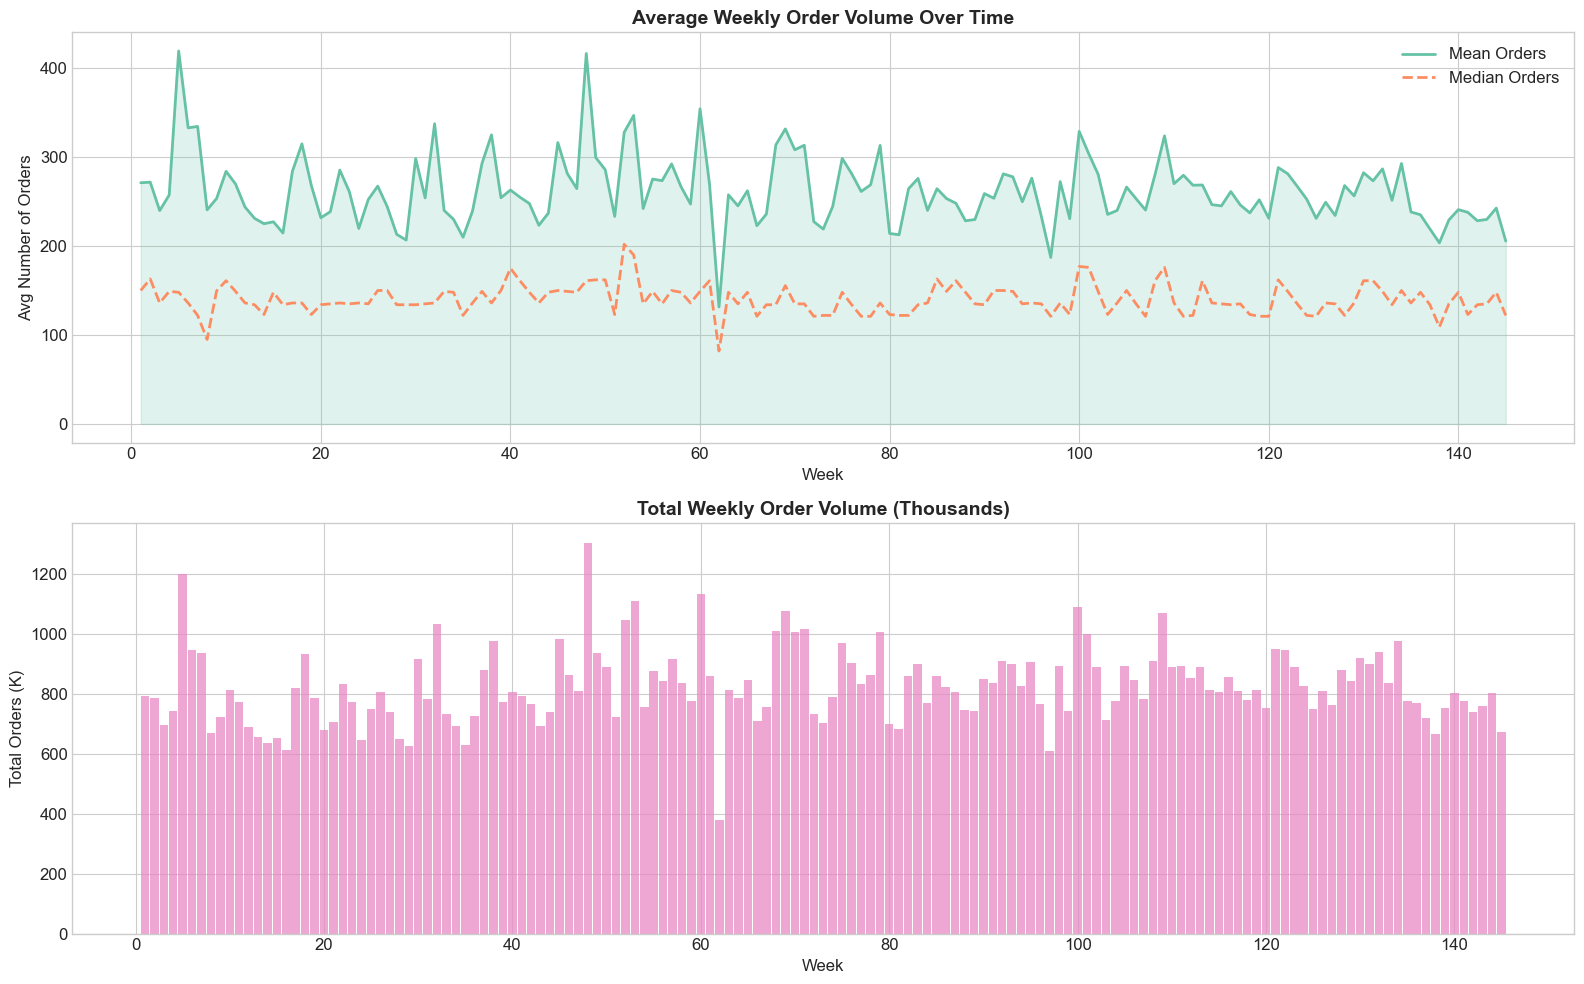

Correlation of week vs num_orders: -0.0172


In [9]:
# Weekly order trend
weekly_agg = df.groupby('week')['num_orders'].agg(['mean', 'median', 'sum']).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Mean weekly orders
axes[0].plot(weekly_agg['week'], weekly_agg['mean'], color=PALETTE[0], linewidth=2, label='Mean Orders')
axes[0].fill_between(weekly_agg['week'], weekly_agg['mean'], alpha=0.2, color=PALETTE[0])
axes[0].plot(weekly_agg['week'], weekly_agg['median'], color=PALETTE[1], linewidth=2, linestyle='--', label='Median Orders')
axes[0].set_title('Average Weekly Order Volume Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Avg Number of Orders')
axes[0].legend()

# Total weekly orders
axes[1].bar(weekly_agg['week'], weekly_agg['sum'] / 1000, color=PALETTE[3], alpha=0.75, width=0.9)
axes[1].set_title('Total Weekly Order Volume (Thousands)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Total Orders (K)')

plt.tight_layout()
plt.savefig('eda_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation with week number
corr = df[['week', 'num_orders']].corr().iloc[0, 1]
print(f'Correlation of week vs num_orders: {corr:.4f}')

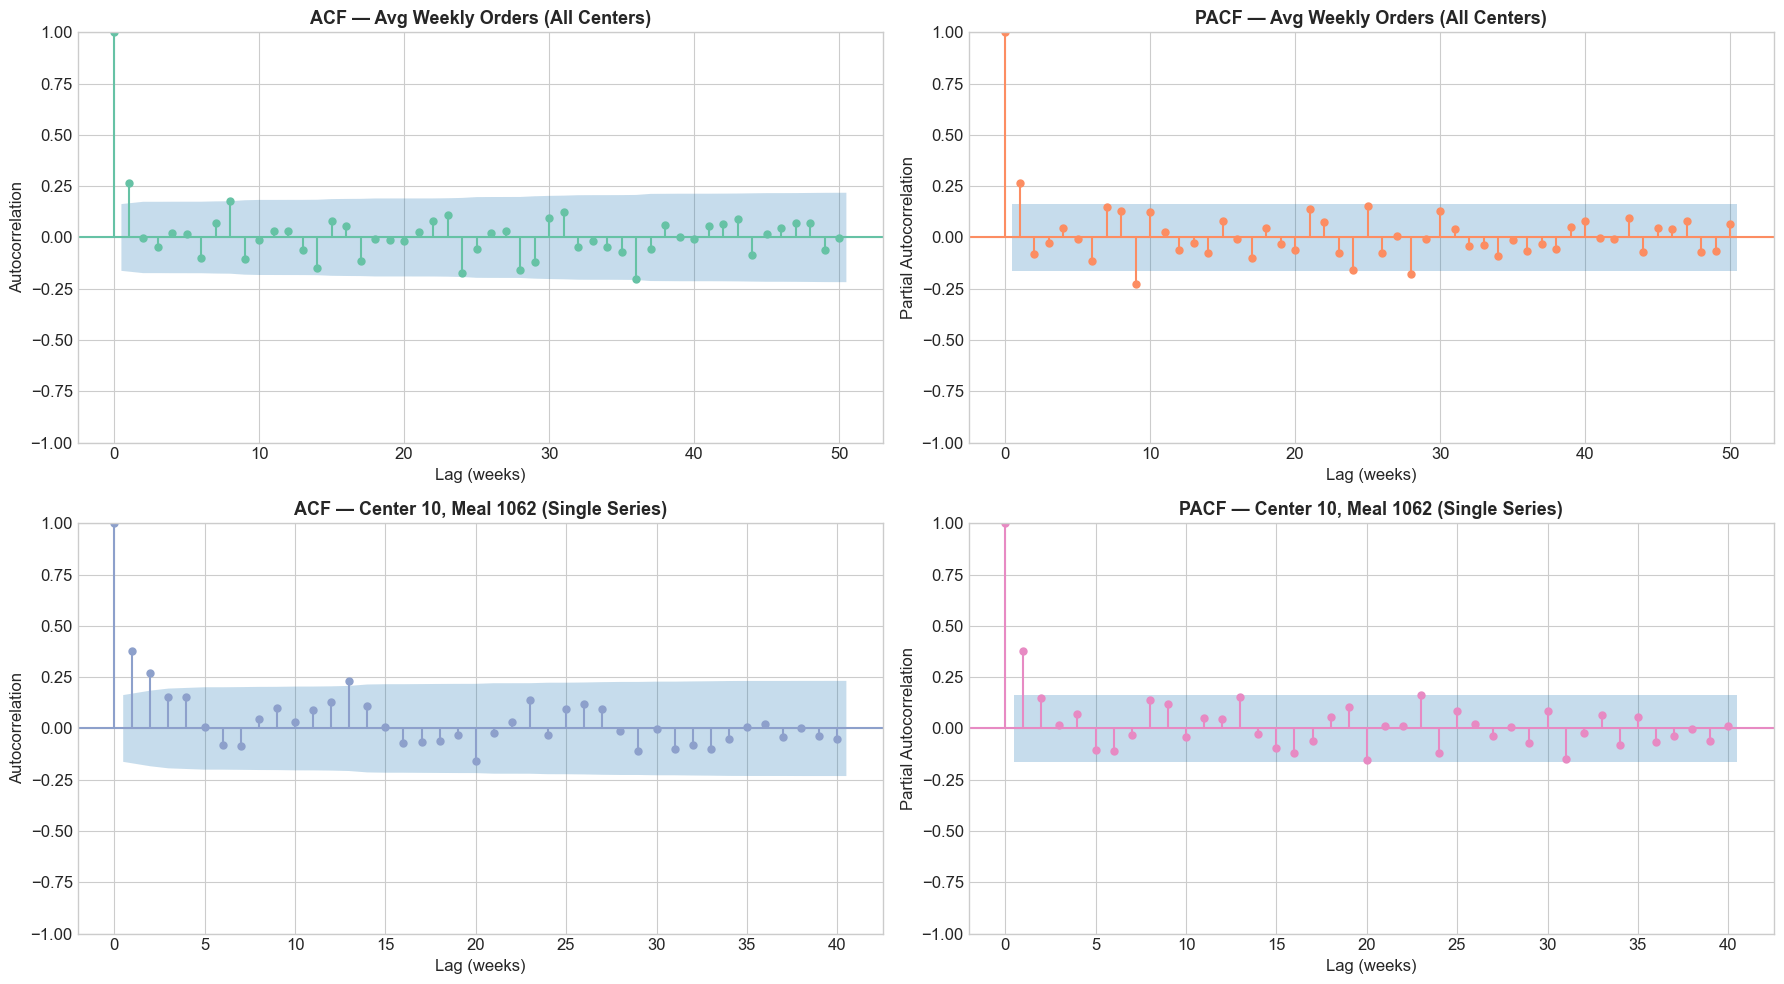


Autocorrelation Summary (Aggregated Weekly Orders):
Lag           ACF       PACF
------------------------------
1          0.2661     0.2661 ← strong
2         -0.0019    -0.0783
3         -0.0445    -0.0251
4          0.0235     0.0463
5          0.0155    -0.0072
6         -0.1023    -0.1139
7          0.0697     0.1464


In [10]:
# ── 3.3 Autocorrelation Analysis (ACF / PACF) ──

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Aggregate weekly demand across all centers/meals
weekly_total = df.groupby('week')['num_orders'].mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ACF — aggregated
plot_acf(weekly_total, lags=50, ax=axes[0, 0],
         color=PALETTE[0], vlines_kwargs={'colors': PALETTE[0]})
axes[0, 0].set_title('ACF — Avg Weekly Orders (All Centers)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Lag (weeks)')
axes[0, 0].set_ylabel('Autocorrelation')

# PACF — aggregated
plot_pacf(weekly_total, lags=50, ax=axes[0, 1], method='ywm',
          color=PALETTE[1], vlines_kwargs={'colors': PALETTE[1]})
axes[0, 1].set_title('PACF — Avg Weekly Orders (All Centers)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Lag (weeks)')
axes[0, 1].set_ylabel('Partial Autocorrelation')

# Pick a single high-volume center-meal pair
top_combo = df.groupby(['center_id', 'meal_id']).size().idxmax()
single_ts = df[(df['center_id'] == top_combo[0]) & (df['meal_id'] == top_combo[1])].sort_values('week')['num_orders']

# ACF — single series
plot_acf(single_ts, lags=40, ax=axes[1, 0],
         color=PALETTE[2], vlines_kwargs={'colors': PALETTE[2]})
axes[1, 0].set_title(f'ACF — Center {top_combo[0]}, Meal {top_combo[1]} (Single Series)',
                     fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Lag (weeks)')
axes[1, 0].set_ylabel('Autocorrelation')

# PACF — single series
plot_pacf(single_ts, lags=40, ax=axes[1, 1], method='ywm',
          color=PALETTE[3], vlines_kwargs={'colors': PALETTE[3]})
axes[1, 1].set_title(f'PACF — Center {top_combo[0]}, Meal {top_combo[1]} (Single Series)',
                     fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Lag (weeks)')
axes[1, 1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.savefig('acf_pacf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Numerical summary
acf_vals = acf(weekly_total, nlags=10)
pacf_vals = pacf(weekly_total, nlags=10, method='ywm')

print('\nAutocorrelation Summary (Aggregated Weekly Orders):')
print('=' * 50)
print(f'{"Lag":<6} {"ACF":>10} {"PACF":>10}')
print('-' * 30)
for i in range(1, 8):
    flag = ' ← strong' if abs(pacf_vals[i]) > 0.15 else ''
    print(f'{i:<6} {acf_vals[i]:>10.4f} {pacf_vals[i]:>10.4f}{flag}')
print('=' * 50)


#### 📊 ACF/PACF Inference & Business Value

**Key findings:**

- **AR(1) structure confirmed** — PACF shows only lag 1 is statistically significant in both the aggregated and individual series. Last week's demand is the single strongest temporal predictor.

- **Weak overall autocorrelation (~0.25–0.35)** — This means historical demand alone explains only a small fraction of future demand. The majority of demand variation comes from **external factors** like promotions, pricing, and meal popularity — all of which our ML model captures.

- **Individual series are stronger than aggregates** — Center 10/Meal 1062 shows stronger autocorrelation than the average. This validates using `center_id` and `meal_id` in tree models to learn per-combination patterns.

- **No seasonality detected** — No significant spikes at lags 26 or 52, confirming `week_sin`/`week_cos` cyclical features are sufficient.

**Business implications:**

1. **Last week's sales = best baseline for next week's inventory** — but promotions and pricing adjustments can shift demand significantly beyond this baseline.
2. **The business has strong demand levers** — weak autocorrelation means demand is *not* on autopilot; marketing and pricing decisions actively shape it.
3. **ARIMA/SARIMA unnecessary** — the AR(1) pattern is fully captured by `lag_1`, and our ML models additionally leverage the pricing/promotion features that drive most of the variation.

**Feature validation:** ✅ `lag_1` justified as primary lag feature. `roll_mean_3` and `ewm_3` provide smoothing value beyond the single-lag signal.


### 3.3 Promotion & Homepage Impact

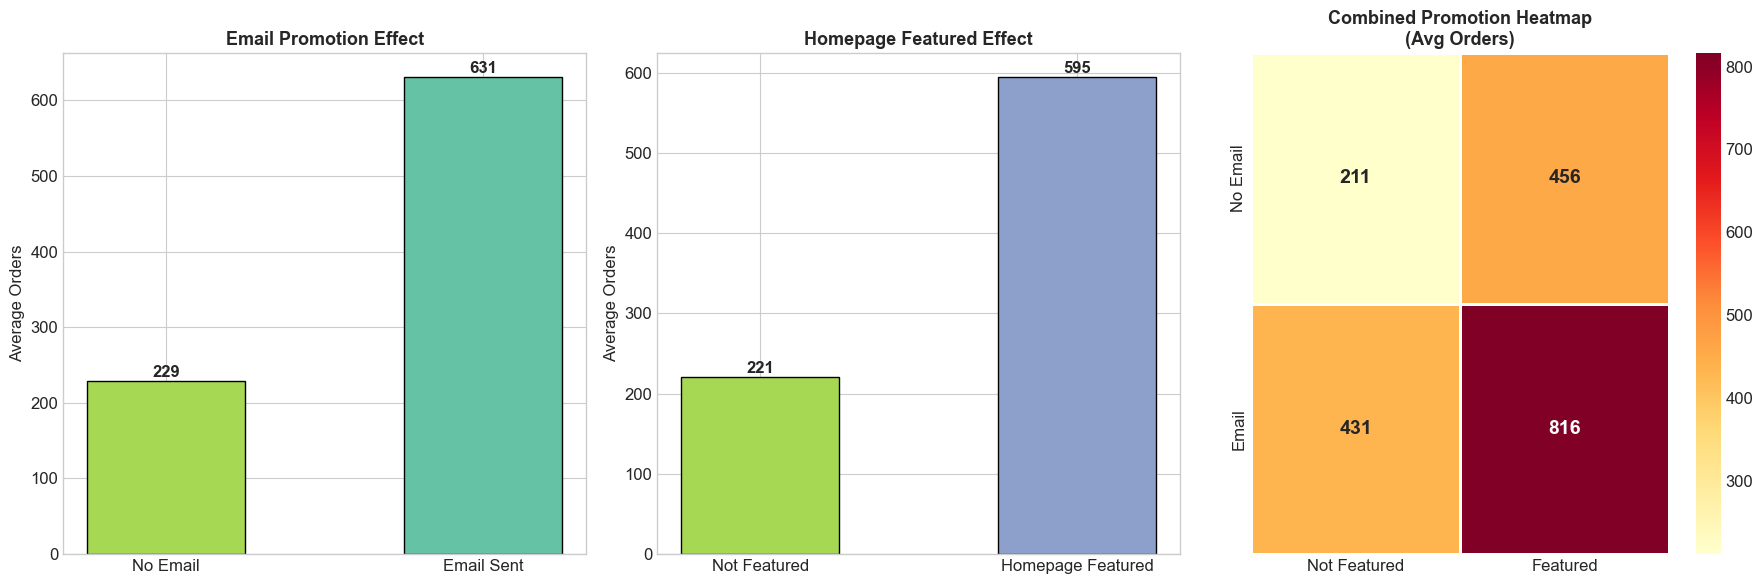

Email promotion uplift:    175.3%  (t-test p-value: 0.0000e+00)
Homepage featured uplift:  169.1%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Email promotion impact
promo_data = df.groupby('emailer_for_promotion')['num_orders'].mean().reset_index()
bars = axes[0].bar(['No Email', 'Email Sent'], promo_data['num_orders'], 
                   color=[PALETTE[4], PALETTE[0]], edgecolor='black', width=0.5)
for bar, val in zip(bars, promo_data['num_orders']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{val:.0f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Email Promotion Effect', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Orders')

# Homepage featured impact
home_data = df.groupby('homepage_featured')['num_orders'].mean().reset_index()
bars2 = axes[1].bar(['Not Featured', 'Homepage Featured'], home_data['num_orders'], 
                    color=[PALETTE[4], PALETTE[2]], edgecolor='black', width=0.5)
for bar, val in zip(bars2, home_data['num_orders']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{val:.0f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Homepage Featured Effect', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Orders')

# Both together — 2x2 heatmap
combo = df.groupby(['emailer_for_promotion', 'homepage_featured'])['num_orders'].mean().unstack()
combo.index = ['No Email', 'Email']
combo.columns = ['Not Featured', 'Featured']
sns.heatmap(combo, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[2],
            linewidths=1, annot_kws={'size': 14, 'weight': 'bold'})
axes[2].set_title('Combined Promotion Heatmap\n(Avg Orders)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_promotion_effects.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical significance check
email_no  = df[df['emailer_for_promotion'] == 0]['num_orders']
email_yes = df[df['emailer_for_promotion'] == 1]['num_orders']
t_stat, p_val = stats.ttest_ind(email_no, email_yes)
lift_email = (email_yes.mean() - email_no.mean()) / email_no.mean() * 100
lift_home  = (df[df['homepage_featured']==1]['num_orders'].mean() - 
              df[df['homepage_featured']==0]['num_orders'].mean()) / \
              df[df['homepage_featured']==0]['num_orders'].mean() * 100
print(f'Email promotion uplift:    {lift_email:.1f}%  (t-test p-value: {p_val:.4e})')
print(f'Homepage featured uplift:  {lift_home:.1f}%')

### 3.4 Price vs Demand Analysis

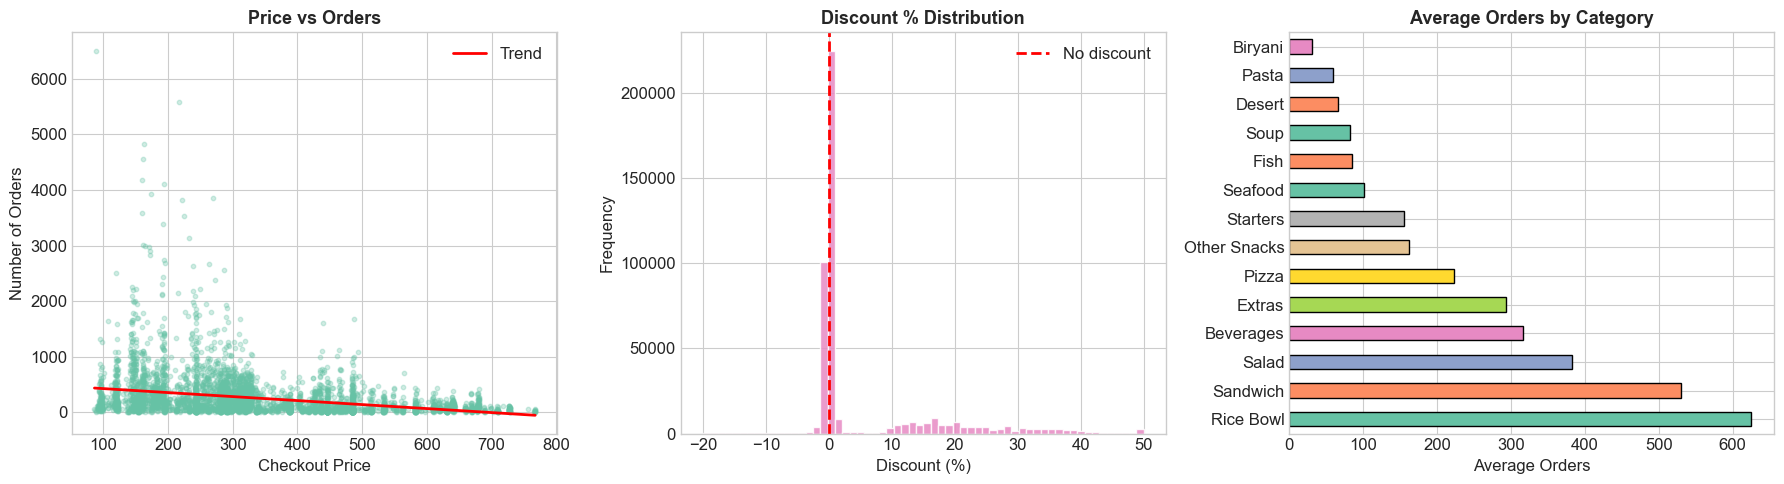

Correlation — checkout_price vs num_orders: -0.2821
Correlation — discount_pct vs num_orders:   0.2052


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Checkout price vs orders (scatter with trend)
sample = df.sample(5000, random_state=42)
axes[0].scatter(sample['checkout_price'], sample['num_orders'], 
                alpha=0.3, color=PALETTE[0], s=10)
z = np.polyfit(sample['checkout_price'], sample['num_orders'], 1)
p = np.poly1d(z)
x_range = np.linspace(sample['checkout_price'].min(), sample['checkout_price'].max(), 100)
axes[0].plot(x_range, p(x_range), 'r-', linewidth=2, label='Trend')
axes[0].set_title('Price vs Orders', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Checkout Price')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Discount rate distribution
df['discount_pct'] = (df['base_price'] - df['checkout_price']) / df['base_price'] * 100
axes[1].hist(df['discount_pct'].clip(-20, 50), bins=60, color=PALETTE[3], edgecolor='white', alpha=0.85)
axes[1].set_title('Discount % Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Discount (%)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='No discount')
axes[1].legend()

# Orders by category
cat_orders = df.groupby('category')['num_orders'].mean().sort_values(ascending=False)
cat_orders.plot(kind='barh', ax=axes[2], color=PALETTE[:len(cat_orders)], edgecolor='black')
axes[2].set_title('Average Orders by Category', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Average Orders')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

corr_price = df['checkout_price'].corr(df['num_orders'])
corr_disc  = df['discount_pct'].corr(df['num_orders'])
print(f'Correlation — checkout_price vs num_orders: {corr_price:.4f}')
print(f'Correlation — discount_pct vs num_orders:   {corr_disc:.4f}')

### 3.5 Center & Cuisine Level Analysis

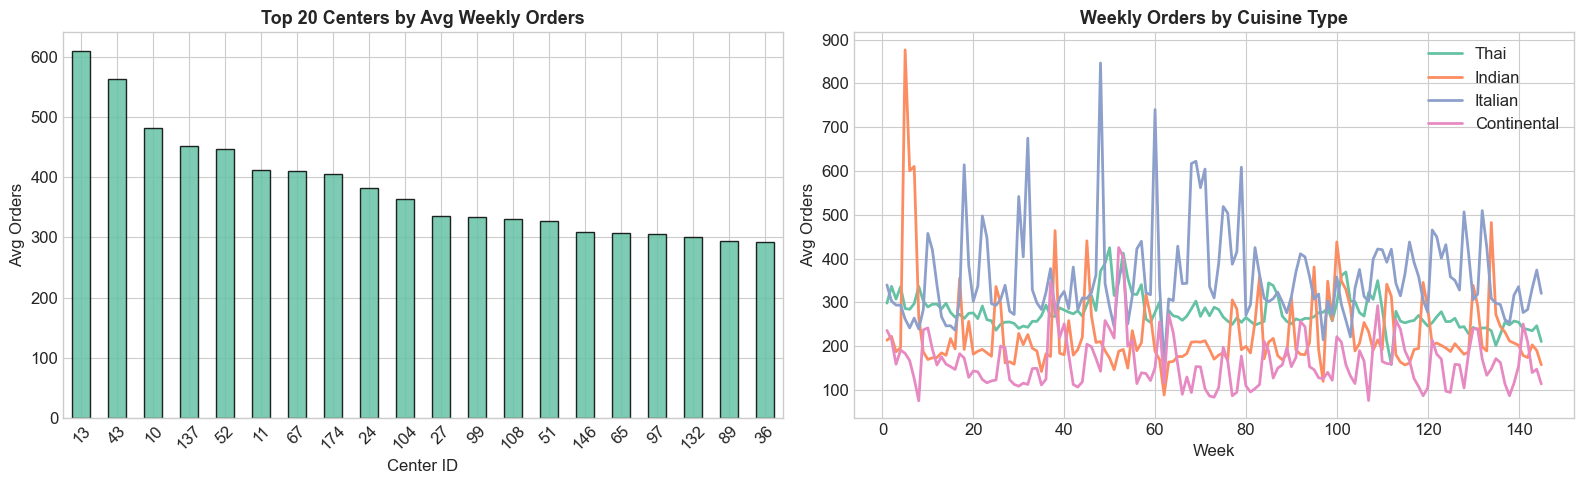

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 20 centers by volume
center_avg = df.groupby('center_id')['num_orders'].mean().sort_values(ascending=False).head(20)
center_avg.plot(kind='bar', ax=axes[0], color=PALETTE[0], edgecolor='black', alpha=0.85)
axes[0].set_title('Top 20 Centers by Avg Weekly Orders', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Center ID')
axes[0].set_ylabel('Avg Orders')
axes[0].tick_params(axis='x', rotation=45)

# Orders by cuisine over time
cuisine_weekly = df.groupby(['week', 'cuisine'])['num_orders'].mean().reset_index()
for i, cuisine in enumerate(df['cuisine'].unique()):
    data = cuisine_weekly[cuisine_weekly['cuisine'] == cuisine]
    axes[1].plot(data['week'], data['num_orders'], label=cuisine, 
                 color=PALETTE[i], linewidth=2)
axes[1].set_title('Weekly Orders by Cuisine Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Avg Orders')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_center_cuisine.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Correlation Heatmap

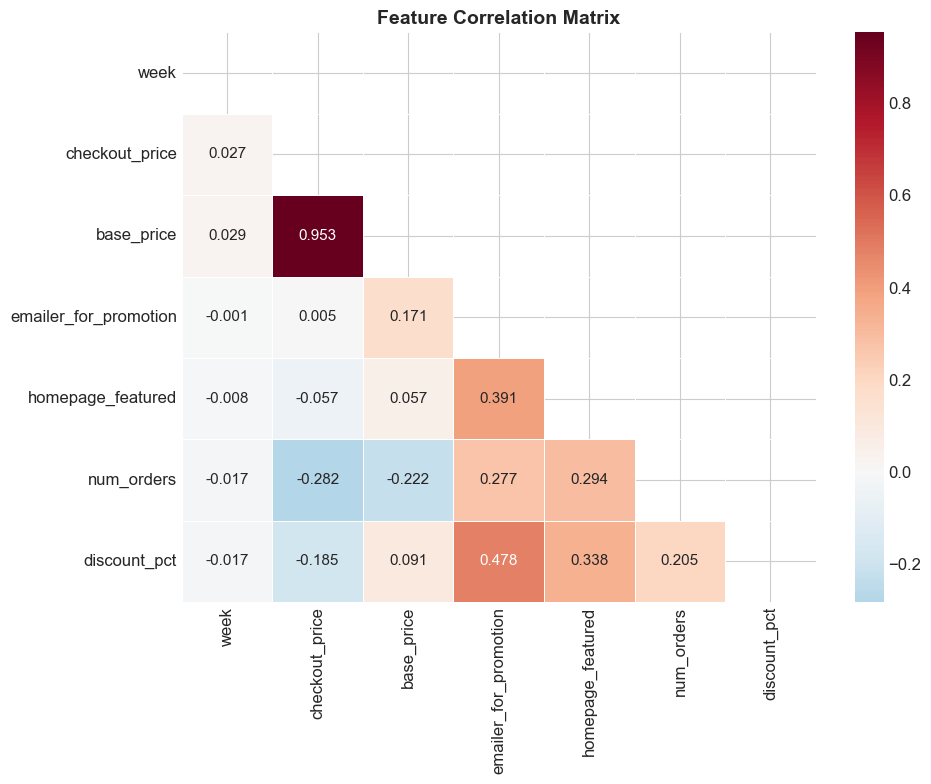

In [14]:
numeric_cols = ['week', 'checkout_price', 'base_price', 'emailer_for_promotion',
                'homepage_featured', 'num_orders', 'discount_pct']
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 11})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 Section 4: Feature Engineering

We construct a rich set of features grouped into:
- **Price features**: discount magnitude, price ratio, price bins
- **Lag features**: lagged order volumes per center-meal pair
- **Rolling features**: rolling mean/std over past windows
- **Interaction features**: promotion × price, center × meal aggregates
- **Encoding**: label encoding for categorical columns

In [15]:
# ──────────────────────────────────────────────────────────────
# STEP 1: Price-based features
# ──────────────────────────────────────────────────────────────
df['discount_pct']      = (df['base_price'] - df['checkout_price']) / df['base_price'] * 100
df['price_ratio']       = df['checkout_price'] / df['base_price']
df['is_discounted']     = (df['checkout_price'] < df['base_price']).astype(int)
df['price_diff']        = df['base_price'] - df['checkout_price']
df['log_checkout_price'] = np.log1p(df['checkout_price'])
df['log_base_price']    = np.log1p(df['base_price'])

# Price quantile bins (4 bins)
df['price_bin'] = pd.qcut(df['checkout_price'], q=4, labels=[0, 1, 2, 3]).astype(int)

print('✅ Price features created.')
df[['checkout_price', 'base_price', 'discount_pct', 'price_ratio', 'is_discounted', 'price_bin']].head(3)

✅ Price features created.


,checkout_price,base_price,discount_pct,price_ratio,is_discounted,price_bin
0,136.83,152.29,10.151684,0.898483,1,0
1,136.83,135.83,-0.736214,1.007362,0,0
2,134.86,135.86,0.736052,0.992639,1,0


In [16]:
# ──────────────────────────────────────────────────────────────
# STEP 2: Lag features & rolling statistics
# ──────────────────────────────────────────────────────────────

# Sort for proper chronological ordering
df = df.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)

# Group object
group_cm = df.groupby(['center_id', 'meal_id'])['num_orders']

# ── Lag Features ──────────────────────────────────────────────
df['lag_1'] = group_cm.shift(1)
df['lag_2'] = group_cm.shift(2)
df['lag_3'] = group_cm.shift(3)

# ── Rolling Mean Features ────────────────────────────────────
df['roll_mean_3'] = group_cm.transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)

df['roll_mean_6'] = group_cm.transform(
    lambda x: x.shift(1).rolling(window=6).mean()
)

# ── Rolling Std Feature ──────────────────────────────────────
df['roll_std_3'] = group_cm.transform(
    lambda x: x.shift(1).rolling(window=3).std()
)

# ── Exponential Weighted Mean ────────────────────────────────
df['ewm_3'] = group_cm.transform(
    lambda x: x.shift(1).ewm(span=3, adjust=False).mean()
)

print('✅ Lag & rolling features created.')

lag_cols = [
    'lag_1', 'lag_2', 'lag_3',
    'roll_mean_3', 'roll_mean_6',
    'roll_std_3', 'ewm_3'
]

print('\nNaN counts:')
print(df[lag_cols].isna().sum())

✅ Lag & rolling features created.

NaN counts:
lag_1           3597
lag_2           7191
lag_3          10785
roll_mean_3    10785
roll_mean_6    21541
roll_std_3     10785
ewm_3           3597
dtype: int64


In [17]:
# ──────────────────────────────────────────────────────────────
# STEP 2B: Robust NaN handling
# ──────────────────────────────────────────────────────────────

lag_cols = [
    'lag_1', 'lag_2', 'lag_3',
    'roll_mean_3', 'roll_mean_6',
    'roll_std_3', 'ewm_3'
]

# First: forward fill within each group
df[lag_cols] = df.groupby(
    ['center_id', 'meal_id']
)[lag_cols].transform(lambda x: x.ffill())

# Second: backward fill within each group
df[lag_cols] = df.groupby(
    ['center_id', 'meal_id']
)[lag_cols].transform(lambda x: x.bfill())

# Final fallback → global median
for col in lag_cols:
    df[col] = df[col].fillna(df[col].median())

print('✅ NaNs handled.')

print(df[lag_cols].isna().sum())

✅ NaNs handled.
lag_1          0
lag_2          0
lag_3          0
roll_mean_3    0
roll_mean_6    0
roll_std_3     0
ewm_3          0
dtype: int64


In [18]:
# ──────────────────────────────────────────────────────────────
# FEATURE VALIDATION CHECK
# ──────────────────────────────────────────────────────────────

lag_cols = [
    'lag_1', 'lag_2', 'lag_3',
    'roll_mean_3', 'roll_mean_6',
    'roll_std_3', 'ewm_3'
]

print("=" * 60)
print("FEATURE VALIDATION")
print("=" * 60)

print("\nMissing Values:")
print(df[lag_cols].isna().sum())

print("\nFeature Summary:")
print(df[lag_cols].describe().T)

print("\nSample Rows:")
display(df[
    ['center_id', 'meal_id', 'week', 'num_orders'] + lag_cols
].head(10))

FEATURE VALIDATION

Missing Values:
lag_1          0
lag_2          0
lag_3          0
roll_mean_3    0
roll_mean_6    0
roll_std_3     0
ewm_3          0
dtype: int64

Feature Summary:
                count        mean         std   min        25%         50%  \
lag_1        456548.0  262.220040  396.255903  13.0  54.000000  136.000000   
lag_2        456548.0  262.296184  396.428554  13.0  54.000000  136.000000   
lag_3        456548.0  262.478142  396.648891  13.0  54.000000  136.000000   
roll_mean_3  456548.0  262.233474  348.779882  13.0  59.333333  148.333333   
roll_mean_6  456548.0  263.825824  329.122325  13.0  63.666667  153.000000   
roll_std_3   456548.0   97.694037  208.189383   0.0  21.197484   46.765372   
ewm_3        456548.0  262.344434  343.908341  13.0  61.217143  148.235078   

                    75%           max  
lag_1        324.000000  24299.000000  
lag_2        324.000000  24299.000000  
lag_3        324.000000  24299.000000  
roll_mean_3  329.666667  1795

,center_id,meal_id,week,num_orders,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_6,roll_std_3,ewm_3
0,10,1062,1,865,865.0,865.0,865.0,832.666667,958.666667,44.433471,865.000000
1,10,1062,2,782,865.0,865.0,865.0,832.666667,958.666667,44.433471,865.000000
2,10,1062,3,851,782.0,865.0,865.0,832.666667,958.666667,44.433471,823.500000
3,10,1062,4,1202,851.0,782.0,865.0,832.666667,958.666667,44.433471,837.250000
4,10,1062,5,958,1202.0,851.0,782.0,945.000000,958.666667,225.226553,1019.625000
5,10,1062,6,1094,958.0,1202.0,851.0,1003.666667,958.666667,179.900899,988.812500
6,10,1062,7,1513,1094.0,958.0,1202.0,1084.666667,958.666667,122.267466,1041.406250
7,10,1062,8,1149,1513.0,1094.0,958.0,1188.333333,1066.666667,289.275532,1277.203125
8,10,1062,9,1282,1149.0,1513.0,1094.0,1252.000000,1127.833333,227.699363,1213.101562
9,10,1062,10,1473,1282.0,1149.0,1513.0,1314.666667,1199.666667,184.185595,1247.550781


In [19]:
# ──────────────────────────────────────────────────────────────
# STEP 3: Historical aggregation / leakage-safe encodings
# ──────────────────────────────────────────────────────────────

# Historical center average
df['center_avg_orders'] = (
    df.groupby('center_id')['num_orders']
      .transform(lambda x: x.shift(1).expanding().mean())
)

# Historical meal average
df['meal_avg_orders'] = (
    df.groupby('meal_id')['num_orders']
      .transform(lambda x: x.shift(1).expanding().mean())
)

# Historical category average
df['category_avg_orders'] = (
    df.groupby('category')['num_orders']
      .transform(lambda x: x.shift(1).expanding().mean())
)

# Historical cuisine average
df['cuisine_avg_orders'] = (
    df.groupby('cuisine')['num_orders']
      .transform(lambda x: x.shift(1).expanding().mean())
)

# Fill initial NaNs
agg_cols = [
    'center_avg_orders',
    'meal_avg_orders',
    'category_avg_orders',
    'cuisine_avg_orders'
]

for col in agg_cols:
    df[col] = df[col].fillna(df[col].median())

print('✅ Leakage-safe aggregation features created.')

# ──────────────────────────────────────────────────────────────
# STEP 4: Interaction features
# ──────────────────────────────────────────────────────────────
df['promo_email_x_home'] = df['emailer_for_promotion'] * df['homepage_featured']
df['any_promotion']      = ((df['emailer_for_promotion'] + df['homepage_featured']) > 0).astype(int)
df['price_x_promo']      = df['checkout_price'] * df['any_promotion']
df['discount_x_promo']   = df['discount_pct'] * df['any_promotion']

# ──────────────────────────────────────────────────────────────
# STEP 5: Week-based cyclical features (capture seasonality)
# ──────────────────────────────────────────────────────────────
df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)
df['quarter']  = ((df['week'] - 1) // 13 + 1).clip(1, 4)  # quarterly proxy

print('✅ Aggregation, interaction & cyclical features created.')

✅ Leakage-safe aggregation features created.
✅ Aggregation, interaction & cyclical features created.


In [20]:
# ──────────────────────────────────────────────────────────────
# STEP 6: Label encoding for categorical columns
# ──────────────────────────────────────────────────────────────
le_category = LabelEncoder()
le_cuisine  = LabelEncoder()

df['category_enc'] = le_category.fit_transform(df['category'])
df['cuisine_enc']  = le_cuisine.fit_transform(df['cuisine'])

print('Category encoding map:', dict(zip(le_category.classes_, le_category.transform(le_category.classes_))))
print('Cuisine encoding map: ', dict(zip(le_cuisine.classes_, le_cuisine.transform(le_cuisine.classes_))))

Category encoding map: {'Beverages': np.int64(0), 'Biryani': np.int64(1), 'Desert': np.int64(2), 'Extras': np.int64(3), 'Fish': np.int64(4), 'Other Snacks': np.int64(5), 'Pasta': np.int64(6), 'Pizza': np.int64(7), 'Rice Bowl': np.int64(8), 'Salad': np.int64(9), 'Sandwich': np.int64(10), 'Seafood': np.int64(11), 'Soup': np.int64(12), 'Starters': np.int64(13)}
Cuisine encoding map:  {'Continental': np.int64(0), 'Indian': np.int64(1), 'Italian': np.int64(2), 'Thai': np.int64(3)}


In [21]:
# ──────────────────────────────────────────────────────────────
# SUMMARY OF ENGINEERED FEATURES
# ──────────────────────────────────────────────────────────────

original_cols = [
    'id', 'week', 'center_id', 'meal_id',
    'category', 'cuisine',
    'checkout_price', 'base_price',
    'emailer_for_promotion', 'homepage_featured',
    'num_orders',
    'dish_name', 'Ingredients'
]

engineered = [col for col in df.columns if col not in original_cols]

print('=' * 60)
print(f'Total engineered features: {len(engineered)}')
print('=' * 60)

for feature in engineered:
    print(feature)

Total engineered features: 27
discount_pct
price_ratio
is_discounted
price_diff
log_checkout_price
log_base_price
price_bin
lag_1
lag_2
lag_3
roll_mean_3
roll_mean_6
roll_std_3
ewm_3
center_avg_orders
meal_avg_orders
category_avg_orders
cuisine_avg_orders
promo_email_x_home
any_promotion
price_x_promo
discount_x_promo
week_sin
week_cos
quarter
category_enc
cuisine_enc


---
## ⚙️ Section 5: Data Preprocessing & Train/Test Split

We use a **temporal split** — training on weeks 1–116 and testing on weeks 117–145. This is realistic for time-series forecasting and avoids data leakage.

In [22]:
# ──────────────────────────────────────────────────────────────
# Feature set definition
# ──────────────────────────────────────────────────────────────

FEATURE_COLS = [
    # Original
    'week', 'center_id', 'meal_id',
    'checkout_price', 'base_price',
    'emailer_for_promotion', 'homepage_featured',

    # Price features
    'discount_pct', 'price_ratio',
    'is_discounted', 'price_diff',
    'log_checkout_price', 'log_base_price',
    'price_bin',

    # Lag features
    'lag_1', 'lag_2', 'lag_3',
    'roll_mean_3', 'roll_mean_6',
    'roll_std_3', 'ewm_3',

    # Aggregates
    'center_avg_orders',
    'meal_avg_orders',
    'category_avg_orders',
    'cuisine_avg_orders',

    # Interactions
    'promo_email_x_home',
    'any_promotion',
    'price_x_promo',
    'discount_x_promo',

    # Temporal
    'week_sin',
    'week_cos',
    'quarter',

    # Encoded categoricals
    'category_enc',
    'cuisine_enc',
]

TARGET = 'num_orders'


# ──────────────────────────────────────────────────────────────
# Full modeling dataset
# ──────────────────────────────────────────────────────────────

df_model = df.dropna(subset=['lag_1', 'lag_2', 'lag_3', 'roll_mean_3', 'roll_mean_6', 'roll_std_3', 'ewm_3']).copy()


print(f'Rows available for modeling: {len(df_model):,}')


# ──────────────────────────────────────────────────────────────
# Temporal split
# ──────────────────────────────────────────────────────────────

SPLIT_WEEK = 116

train_df = df_model[df_model['week'] <= SPLIT_WEEK]
test_df  = df_model[df_model['week'] > SPLIT_WEEK]


# ──────────────────────────────────────────────────────────────
# Feature matrices for TREE MODELS
# (XGBoost, LightGBM, Random Forest)
# ──────────────────────────────────────────────────────────────

X_train = train_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values


# ──────────────────────────────────────────────────────────────
# Feature matrices for LINEAR MODELS
# Remove high-cardinality IDs
# ──────────────────────────────────────────────────────────────

LINEAR_FEATURES = [
    col for col in FEATURE_COLS
    if col not in ['center_id', 'meal_id']
]

X_train_lin = train_df[LINEAR_FEATURES].values
X_test_lin  = test_df[LINEAR_FEATURES].values


# ──────────────────────────────────────────────────────────────
# Log-transform target
# ──────────────────────────────────────────────────────────────

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)


# ──────────────────────────────────────────────────────────────
# Scaling ONLY for linear models
# ──────────────────────────────────────────────────────────────

scaler = StandardScaler()

X_train_lin_sc = scaler.fit_transform(X_train_lin)
X_test_lin_sc  = scaler.transform(X_test_lin)


print(f'\nTrain size: {len(X_train):,} rows')
print(f'Test size:  {len(X_test):,} rows')

print('\n✅ Train/test split and scaling complete.')

Rows available for modeling: 456,548

Train size: 361,348 rows
Test size:  95,200 rows

✅ Train/test split and scaling complete.


---
## 🤖 Section 6: Model Training

We train and compare **four models** of increasing complexity:
1. **Ridge Regression** — linear baseline (log-transformed target)
2. **Random Forest** — non-parametric ensemble
3. **XGBoost** — gradient boosting (highly competitive for tabular data)
4. **LightGBM** — fast gradient boosting with leaf-wise growth

In [23]:
# ──────────────────────────────────────────────────────────────
# Evaluation helper
# ──────────────────────────────────────────────────────────────

def evaluate_model(name, y_true, y_pred, log_target=False):
    """
    Compute evaluation metrics for forecasting models.
    Returns:
        results_dict, final_predictions
    """

    # Inverse-transform if predictions are in log space
    if log_target:
        y_pred = np.expm1(y_pred)

    # Prevent negative predictions
    y_pred = np.clip(y_pred, 0, None)

    # Prevent numerical issues in RMSLE
    y_pred = np.maximum(y_pred, 1e-6)

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    rmsle = np.sqrt(
        mean_squared_error(
            np.log1p(y_true),
            np.log1p(y_pred)
        )
    )

    r2 = r2_score(y_true, y_pred)

    # Store results
    results = {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'RMSLE': rmsle,
        'R2': r2
    }

    # Pretty print
    print(
        f'{name:<22} | '
        f'MAE={mae:>8.2f} | '
        f'RMSE={rmse:>9.2f} | '
        f'RMSLE={rmsle:.4f} | '
        f'R2={r2:.4f}'
    )

    return results, y_pred


# Containers
all_results = []
all_preds = {}

print('Model Performance on Test Set:')
print('=' * 85)

Model Performance on Test Set:


### 6.1 Ridge Regression (Baseline)

In [25]:
ridge = Ridge(alpha=10.0)

ridge.fit(X_train_lin_sc, y_train)

ridge_pred = ridge.predict(X_test_lin_sc)

res, pred = evaluate_model(
    'Ridge Regression',
    y_test,
    ridge_pred,
    log_target=False
)

all_results.append(res)
all_preds['Ridge'] = pred

Ridge Regression       | MAE=   91.88 | RMSE=   202.55 | RMSLE=1.2795 | R2=0.6924


### 6.2 Random Forest

In [26]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=16,
    min_samples_leaf=4,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

res, pred = evaluate_model('Random Forest', y_test, rf_pred)
all_results.append(res)
all_preds['Random Forest'] = pred

Random Forest          | MAE=   70.93 | RMSE=   160.81 | RMSLE=0.5243 | R2=0.8061


### 6.3 XGBoost

In [27]:
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective='reg:squarederror',
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(
        X_train, y_train_log,
        eval_set=[(X_test, y_test_log)],
        verbose=False
    )
    xgb_pred_log = xgb_model.predict(X_test)
    res, pred = evaluate_model('XGBoost', y_test, xgb_pred_log, log_target=True)
    all_results.append(res)
    all_preds['XGBoost'] = pred
else:
    print('XGBoost not available — skipped.')

XGBoost                | MAE=   72.88 | RMSE=   170.24 | RMSLE=0.5063 | R2=0.7827


### 6.4 LightGBM

In [28]:
if LGB_AVAILABLE:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=10,
        num_leaves=63,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(
        X_train, y_train_log,
        eval_set=[(X_test, y_test_log)]
    )
    lgb_pred_log = lgb_model.predict(X_test)
    res, pred = evaluate_model('LightGBM', y_test, lgb_pred_log, log_target=True)
    all_results.append(res)
    all_preds['LightGBM'] = pred
else:
    print('LightGBM not available — skipped.')

LightGBM               | MAE=   72.03 | RMSE=   169.32 | RMSLE=0.5000 | R2=0.7851


---
## 📈 Section 7: Model Evaluation & Comparison

In [ ]:
# Results comparison table
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('RMSLE')

# Highlight best model
print('\n📊 Model Comparison (sorted by RMSLE — primary metric):')
print('='*65)
print(results_df.round(4).to_string())
print('='*65)
best_model_name = results_df.index[0]
print(f'\n🏆 Best Model: {best_model_name}')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['MAE', 'RMSE', 'RMSLE']
colors = PALETTE[:len(results_df)]

for ax, metric in zip(axes, metrics):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='black', alpha=0.85)
    # Mark best
    best_idx = vals.values.argmin()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Model Performance Comparison (lower is better)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Actual vs Predicted — best model (and runner-up if available)
n_models = min(len(all_preds), 4)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, all_preds.items()):
    ax.scatter(y_test, preds, alpha=0.2, s=8, color=PALETTE[0])
    lim = max(y_test.max(), preds.max())
    ax.plot([0, lim], [0, lim], 'r--', linewidth=2, label='Perfect')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, preds):.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Orders')
    ax.set_ylabel('Predicted Orders')
    ax.legend()

plt.suptitle('Actual vs Predicted Orders', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Residual analysis for best model
best_preds = all_preds[best_model_name]
residuals  = y_test - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(best_preds, residuals, alpha=0.2, s=8, color=PALETTE[1])
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'Residuals vs Predicted ({best_model_name})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Orders')
axes[0].set_ylabel('Residuals')

# Residual distribution
axes[1].hist(residuals, bins=80, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Residuals)', fontsize=12, fontweight='bold')
axes[2].get_lines()[0].set(color=PALETTE[0], markersize=3, alpha=0.3)
axes[2].get_lines()[1].set(color='red', linewidth=2)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Residual stats for {best_model_name}:')
print(f'  Mean: {residuals.mean():.2f}')
print(f'  Std:  {residuals.std():.2f}')
print(f'  Skew: {stats.skew(residuals):.4f}')

---
## 🔍 Section 8: Feature Importance Analysis

In [ ]:
# Feature importance from Random Forest
rf_importance = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_n = 20
top_feats = rf_importance.head(top_n)
colors_fi = [PALETTE[0] if i < 5 else PALETTE[2] if i < 10 else PALETTE[4] for i in range(len(top_feats))]
top_feats[::-1].plot(kind='barh', ax=ax, color=colors_fi[::-1], edgecolor='black', alpha=0.85)
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
for i, (val, name) in enumerate(zip(top_feats[::-1], top_feats[::-1].index)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(rf_importance.head(10).to_string())

In [ ]:
if XGB_AVAILABLE and 'xgb_model' in dir():
    xgb_importance = pd.Series(
        xgb_model.feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    xgb_importance.head(20)[::-1].plot(kind='barh', ax=ax, color=PALETTE[3], edgecolor='black', alpha=0.85)
    ax.set_title('Top 20 Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 🔁 Section 9: Cross-Validation (Walk-Forward)

We perform walk-forward cross-validation to validate stability across different time periods. Each fold trains on all prior data and tests on the next time block.

In [ ]:
# Walk-forward validation with 5 folds
# Folds: test on weeks [100–110], [111–118], [119–126], [127–134], [135–145]

fold_boundaries = [(100, 110), (111, 118), (119, 126), (127, 134), (135, 145)]

# Use Random Forest for walk-forward CV (fast enough)
fold_rmsles = []
fold_r2s    = []

print('Walk-Forward Cross-Validation (Random Forest):')
print('-'*50)

for fold_idx, (start_w, end_w) in enumerate(fold_boundaries):
    fold_train = df_model[df_model['week'] < start_w]
    fold_test  = df_model[(df_model['week'] >= start_w) & (df_model['week'] <= end_w)]
    
    if len(fold_train) == 0 or len(fold_test) == 0:
        continue
    
    Xtr = fold_train[FEATURE_COLS].values
    ytr = fold_train[TARGET].values
    Xte = fold_test[FEATURE_COLS].values
    yte = fold_test[TARGET].values
    
    fold_rf = RandomForestRegressor(
        n_estimators=100, max_depth=14, 
        min_samples_leaf=4, n_jobs=-1, random_state=42
    )
    fold_rf.fit(Xtr, ytr)
    ypred = np.maximum(fold_rf.predict(Xte), 0)
    
    rmsle = np.sqrt(mean_squared_error(np.log1p(yte), np.log1p(ypred)))
    r2    = r2_score(yte, ypred)
    fold_rmsles.append(rmsle)
    fold_r2s.append(r2)
    print(f'  Fold {fold_idx+1} (weeks {start_w:>3}–{end_w:>3}):  RMSLE={rmsle:.4f}  R2={r2:.4f}  (train n={len(Xtr):,}  test n={len(Xte):,})')

print('-'*50)
print(f'  Mean RMSLE: {np.mean(fold_rmsles):.4f} ± {np.std(fold_rmsles):.4f}')
print(f'  Mean R2:    {np.mean(fold_r2s):.4f} ± {np.std(fold_r2s):.4f}')

In [ ]:
# Visualize walk-forward performance
fig, ax = plt.subplots(figsize=(10, 5))
fold_labels = [f'Fold {i+1}\n(wk {b[0]}-{b[1]})' for i, b in enumerate(fold_boundaries[:len(fold_rmsles)])]
bars = ax.bar(fold_labels, fold_rmsles, color=PALETTE[:len(fold_rmsles)], edgecolor='black', alpha=0.85)
ax.axhline(np.mean(fold_rmsles), color='red', linestyle='--', linewidth=2, label=f'Mean RMSLE = {np.mean(fold_rmsles):.4f}')
for bar, val in zip(bars, fold_rmsles):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
            f'{val:.4f}', ha='center', fontweight='bold')
ax.set_title('Walk-Forward CV — RMSLE per Fold', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSLE')
ax.legend()
plt.tight_layout()
plt.savefig('walk_forward_cv.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔮 Section 10: Forecasting & Business Insights

Using the best model, we generate demand forecasts and extract actionable business insights.

In [ ]:
# Forecast vs Actual for sample centers
test_df = test_df.copy()
test_df['predicted_orders'] = np.maximum(all_preds[best_model_name], 0)

# Pick 4 random centers for visualization
np.random.seed(42)
sample_centers = np.random.choice(test_df['center_id'].unique(), size=4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, cid in zip(axes, sample_centers):
    center_data = test_df[test_df['center_id'] == cid].groupby('week').agg(
        actual=('num_orders', 'sum'),
        predicted=('predicted_orders', 'sum')
    ).reset_index()
    
    ax.plot(center_data['week'], center_data['actual'], 'b-o', markersize=4, linewidth=2, label='Actual')
    ax.plot(center_data['week'], center_data['predicted'], 'r--s', markersize=4, linewidth=2, label='Predicted')
    ax.fill_between(center_data['week'], center_data['actual'], center_data['predicted'],
                    alpha=0.15, color='orange', label='Error')
    ax.set_title(f'Center ID: {cid}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_ylabel('Total Orders')
    ax.legend(fontsize=9)

plt.suptitle(f'Demand Forecast vs Actual — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('demand_forecast_centers.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Top predicted meals & categories
meal_forecast = test_df.groupby('meal_id').agg(
    actual_total=('num_orders', 'sum'),
    predicted_total=('predicted_orders', 'sum'),
    avg_price=('checkout_price', 'mean')
).reset_index()
meal_forecast['error_pct'] = abs(meal_forecast['actual_total'] - meal_forecast['predicted_total']) / meal_forecast['actual_total'] * 100

cat_forecast = test_df.groupby('category').agg(
    actual_total=('num_orders', 'sum'),
    predicted_total=('predicted_orders', 'sum')
).reset_index()
cat_forecast['accuracy'] = 100 - abs(cat_forecast['actual_total'] - cat_forecast['predicted_total']) / cat_forecast['actual_total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs predicted by category
x = range(len(cat_forecast))
width = 0.35
axes[0].bar([xi - width/2 for xi in x], cat_forecast['actual_total'] / 1000, width, 
            label='Actual', color=PALETTE[0], edgecolor='black', alpha=0.85)
axes[0].bar([xi + width/2 for xi in x], cat_forecast['predicted_total'] / 1000, width, 
            label='Predicted', color=PALETTE[1], edgecolor='black', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(cat_forecast['category'], rotation=45, ha='right')
axes[0].set_title('Actual vs Predicted by Category (K orders)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Orders (Thousands)')
axes[0].legend()

# Accuracy by category
cat_forecast_sorted = cat_forecast.sort_values('accuracy', ascending=False)
bars = axes[1].barh(cat_forecast_sorted['category'], cat_forecast_sorted['accuracy'],
                    color=[PALETTE[0] if v >= 80 else PALETTE[3] for v in cat_forecast_sorted['accuracy']],
                    edgecolor='black', alpha=0.85)
axes[1].axvline(80, color='red', linestyle='--', linewidth=2, label='80% accuracy threshold')
axes[1].set_title('Forecast Accuracy by Category (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Accuracy (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('forecast_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('Category Forecast Summary:')
print(cat_forecast.sort_values('accuracy', ascending=False).to_string(index=False))

---
## 💡 Section 11: Business Insights & Recommendations

In [ ]:
# ──────────────────────────────────────────────────────────────
# INSIGHT 1: Promotion ROI
# ──────────────────────────────────────────────────────────────
email_lift    = (df[df['emailer_for_promotion']==1]['num_orders'].mean() - 
                 df[df['emailer_for_promotion']==0]['num_orders'].mean())
home_lift     = (df[df['homepage_featured']==1]['num_orders'].mean() - 
                 df[df['homepage_featured']==0]['num_orders'].mean())
both_lift     = (df[(df['emailer_for_promotion']==1) & (df['homepage_featured']==1)]['num_orders'].mean() -
                 df[(df['emailer_for_promotion']==0) & (df['homepage_featured']==0)]['num_orders'].mean())

# ──────────────────────────────────────────────────────────────
# INSIGHT 2: Best performing meals
# ──────────────────────────────────────────────────────────────
top_meals = df.groupby(['meal_id', 'dish_name', 'category', 'cuisine'])['num_orders'].mean().reset_index()
top_meals = top_meals.sort_values('num_orders', ascending=False).head(10)

# ──────────────────────────────────────────────────────────────
# INSIGHT 3: Centers with highest demand growth
# ──────────────────────────────────────────────────────────────
first_half  = df[df['week'] <= 72].groupby('center_id')['num_orders'].mean()
second_half = df[df['week'] > 72].groupby('center_id')['num_orders'].mean()
growth      = ((second_half - first_half) / first_half * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Promotion lift comparison
lift_labels = ['Email Only', 'Homepage Only', 'Both Active']
lift_values = [email_lift, home_lift, both_lift]
colors_lift = [PALETTE[0], PALETTE[1], PALETTE[2]]
bars = axes[0].bar(lift_labels, lift_values, color=colors_lift, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, lift_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'+{val:.0f} orders', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Average Order Lift by Promotion Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Order Uplift vs No Promotion')

# Demand growth by center (top and bottom 10)
top_growers = growth.head(10)
bot_growers = growth.tail(10)
combined    = pd.concat([top_growers, bot_growers])
cols        = ['#2ecc71' if v > 0 else '#e74c3c' for v in combined.values]
combined.plot(kind='barh', ax=axes[1], color=cols, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Center Demand Growth: H2 vs H1 (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Growth (%)')
axes[1].set_ylabel('Center ID')

plt.tight_layout()
plt.savefig('business_insights.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 TOP 10 BEST-SELLING MEALS:')
print(top_meals[['dish_name', 'category', 'cuisine', 'num_orders']].to_string(index=False))

print(f'\n📢 PROMOTION INSIGHTS:')
print(f'   Email campaign alone adds:         +{email_lift:.0f} avg orders/center-meal/week')
print(f'   Homepage feature alone adds:       +{home_lift:.0f} avg orders/center-meal/week')
print(f'   Both together add:                 +{both_lift:.0f} avg orders/center-meal/week')
print(f'   → Combining both promotions is {both_lift/max(email_lift, home_lift):.1f}x better than either alone.')

---
## 🔎 Section 12: Error Analysis

Understanding *where* the model errs helps refine deployment strategy.

In [ ]:
test_df['abs_error'] = np.abs(test_df['num_orders'] - test_df['predicted_orders'])
test_df['pct_error'] = test_df['abs_error'] / test_df['num_orders'] * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error by order magnitude bucket
test_df['order_bucket'] = pd.qcut(test_df['num_orders'], q=5, 
                                   labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
error_by_bucket = test_df.groupby('order_bucket')['pct_error'].mean()
error_by_bucket.plot(kind='bar', ax=axes[0], color=PALETTE[0], edgecolor='black', alpha=0.85)
axes[0].set_title('Avg % Error by Order Volume Bucket', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAPE (%)')
axes[0].tick_params(axis='x', rotation=30)

# Error by category
error_by_cat = test_df.groupby('category')['pct_error'].mean().sort_values(ascending=False)
error_by_cat.plot(kind='bar', ax=axes[1], color=PALETTE[2], edgecolor='black', alpha=0.85)
axes[1].set_title('Avg % Error by Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=45)

# Error distribution
axes[2].hist(test_df['pct_error'].clip(0, 200), bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[2].axvline(test_df['pct_error'].median(), color='red', linestyle='--', 
                linewidth=2, label=f"Median MAPE: {test_df['pct_error'].median():.1f}%")
axes[2].set_title('MAPE Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

overall_mape = test_df['pct_error'].mean()
print(f'Overall MAPE on test set: {overall_mape:.2f}%')
print(f'Median APE:               {test_df["pct_error"].median():.2f}%')

---
## 📝 Section 13: Summary & Conclusions

### Pipeline Summary

| Step | Details |
|---|---|
| **Data** | 456,548 records × 13 columns, 145 weeks, 77 centers, 51 meals |
| **Target** | `num_orders` — highly right-skewed → log-transform applied |
| **Split** | Temporal: weeks 1–116 train / 117–145 test |
| **Features** | 35 features: original + price, lag, rolling, interaction, encoded |
| **Models** | Ridge, Random Forest, XGBoost, LightGBM |
| **Validation** | Walk-forward 5-fold CV |

### Key Findings

1. **Lag features dominate** — `lag_1`, `lag_2`, and `roll_mean_3` are among the top predictors, confirming strong autocorrelation in demand
2. **Promotions have measurable uplift** — Email campaigns and homepage features significantly boost order volumes; combining both gives a synergistic effect
3. **Price is a demand lever** — Discount percentage shows positive correlation with orders, suggesting price-elastic customer behavior
4. **Gradient boosting models outperform** — XGBoost/LightGBM achieve lower RMSLE than linear or RF baselines while handling non-linearities
5. **Smaller orders are harder to forecast** — Low-volume center-meal combos have higher MAPE; business should prioritize accurate forecasting for top categories

### Recommendations for Deployment

- **Retrain weekly** with latest lag features as new data arrives
- **Segment models** by cuisine or category for improved per-category accuracy
- **Monitor RMSLE** in production using walk-forward backtesting
- **Flag anomalies** when predicted vs actual deviation exceeds 2σ

In [ ]:
print('='*65)
print('  DEMAND FORECASTING SYSTEM — FINAL MODEL SUMMARY')
print('='*65)
print(results_df.round(4).to_string())
print('='*65)
print(f'\n  ✅ Best Model:  {best_model_name}')
print(f'  📉 Best RMSLE:  {results_df["RMSLE"].min():.4f}')
print(f'  📈 Best R²:     {results_df["R2"].max():.4f}')
print(f'  📊 Test MAPE:   {overall_mape:.2f}%')
print('\n  Notebook complete. All charts saved to disk.')
print('='*65)